# Train a 4-layer GINE (5-fold CV + held-out test)
This section trains a 4-layer GINEConv model using a classic pipeline: for each seed we create a stratified train+val vs test split, run 5-fold CV on train+val (with an inner train/val split per fold), and evaluate each fold's best checkpoint on the held-out test set.
We report accuracy mean ± std across all folds and all seeds.

In [1]:
import os
import time
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINEConv, global_mean_pool

from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def get_device() -> torch.device:
    return torch.device('cuda' if torch.cuda.is_available() else 'cpu')


@torch.no_grad()
def accuracy_from_logits(logits: torch.Tensor, y: torch.Tensor) -> float:
    pred = logits.argmax(dim=-1)
    return (pred == y).float().mean().item()


class GINE4Layer(nn.Module):
    def __init__(
        self,
        in_dim: int,
        edge_dim: int,
        hidden_dim: int,
        num_classes: int,
        num_layers: int = 4,
        dropout: float = 0.2,
    ):
        super().__init__()
        assert num_layers == 4, "This notebook cell implements the requested 4-layer GINE."
        self.dropout = dropout

        self.node_encoder = nn.Linear(in_dim, hidden_dim)
        self.edge_encoder = nn.Linear(edge_dim, hidden_dim)

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(num_layers):
            mlp = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(inplace=True),
                nn.Linear(hidden_dim, hidden_dim),
            )
            self.convs.append(GINEConv(nn=mlp))
            self.norms.append(nn.BatchNorm1d(hidden_dim))

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch = data.x, data.edge_index, data.edge_attr, data.batch
        x = self.node_encoder(x)
        edge_attr = self.edge_encoder(edge_attr)

        for conv, bn in zip(self.convs, self.norms):
            x = conv(x, edge_index, edge_attr)
            x = bn(x)
            x = F.relu(x, inplace=True)
            x = F.dropout(x, p=self.dropout, training=self.training)

        g = global_mean_pool(x, batch)
        return self.classifier(g)

In [2]:
def make_splits_indices(y: np.ndarray, seed: int, test_size: float, k_folds: int):
    """Returns (trainval_idx, test_idx, folds) where folds is list of (train_idx, val_idx) in index space."""
    splitter = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    (trainval_idx, test_idx) = next(splitter.split(np.zeros_like(y), y))

    y_trainval = y[trainval_idx]
    skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=seed)
    folds = []
    for fold_train_rel, fold_val_rel in skf.split(np.zeros_like(y_trainval), y_trainval):
        fold_train_idx = trainval_idx[fold_train_rel]
        fold_val_idx = trainval_idx[fold_val_rel]
        folds.append((fold_train_idx, fold_val_idx))
    return trainval_idx, test_idx, folds


def train_one_run(
    dataset,
    train_idx: np.ndarray,
    val_idx: np.ndarray,
    test_idx: np.ndarray,
    *,
    seed: int,
    hidden_dim: int = 128,
    batch_size: int = 64,
    max_epochs: int = 200,
    lr: float = 1e-3,
    weight_decay: float = 1e-4,
    dropout: float = 0.2,
    scheduler_factor: float = 0.5,
    scheduler_patience: int = 10,
    min_lr: float = 1e-6,
    early_stop_patience: int = 25,
    min_delta: float = 1e-4,
    num_workers: int = 0,
    verbose: bool = False,
    device=None,
 ):
    set_seed(seed)
    device = device or get_device()

    # Infer dims from dataset
    sample = dataset[0]
    in_dim = int(sample.x.size(-1))
    edge_dim = int(sample.edge_attr.size(-1))
    num_classes = int(dataset.num_classes) if hasattr(dataset, 'num_classes') else int(torch.unique(torch.tensor([d.y.item() for d in dataset])).numel())

    model = GINE4Layer(
        in_dim=in_dim,
        edge_dim=edge_dim,
        hidden_dim=hidden_dim,
        num_classes=num_classes,
        num_layers=4,
        dropout=dropout,
    ).to(device)

    train_loader = DataLoader(dataset.index_select(torch.tensor(train_idx)), batch_size=batch_size, shuffle=True, num_workers=num_workers)
    val_loader = DataLoader(dataset.index_select(torch.tensor(val_idx)), batch_size=batch_size, shuffle=False, num_workers=num_workers)
    test_loader = DataLoader(dataset.index_select(torch.tensor(test_idx)), batch_size=batch_size, shuffle=False, num_workers=num_workers)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=scheduler_factor, patience=scheduler_patience, min_lr=min_lr
    )

    best_state = None
    best_val_loss = float('inf')
    best_val_acc = 0.0
    epochs_no_improve = 0

    def run_loader(loader, train: bool):
        if train:
            model.train()
        else:
            model.eval()
        total_loss = 0.0
        total_correct = 0
        total_examples = 0
        for batch in loader:
            batch = batch.to(device)
            logits = model(batch)
            y = batch.y.view(-1).to(device)
            loss = F.cross_entropy(logits, y)
            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * y.size(0)
            total_correct += (logits.argmax(dim=-1) == y).sum().item()
            total_examples += y.size(0)
        avg_loss = total_loss / max(1, total_examples)
        avg_acc = total_correct / max(1, total_examples)
        return avg_loss, avg_acc

    for epoch in range(1, max_epochs + 1):
        train_loss, train_acc = run_loader(train_loader, train=True)
        val_loss, val_acc = run_loader(val_loader, train=False)
        scheduler.step(val_loss)

        improved = (best_val_loss - val_loss) > min_delta
        if improved:
            best_val_loss = val_loss
            best_val_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if verbose and (epoch == 1 or epoch % 10 == 0):
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch:03d} | lr={current_lr:.2e} | train {train_loss:.4f}/{train_acc:.3f} | val {val_loss:.4f}/{val_acc:.3f}")

        if epochs_no_improve >= early_stop_patience:
            if verbose:
                print(f"Early stopping at epoch {epoch} (best val loss {best_val_loss:.4f}, acc {best_val_acc:.3f}).")
            break

    # Load best checkpoint
    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)

    test_loss, test_acc = run_loader(test_loader, train=False)
    return {
        'best_val_loss': float(best_val_loss),
        'best_val_acc': float(best_val_acc),
        'test_loss': float(test_loss),
        'test_acc': float(test_acc),
        'epochs_ran': int(epoch),
    }

In [3]:
def run_multiseed_5fold(
    dataset,
    *,
    seeds=(0, 1, 2),
    k_folds: int = 5,
    test_size: float = 0.2,
    hidden_dim: int = 128,
    batch_size: int = 64,
    max_epochs: int = 200,
    lr: float = 1e-3,
    weight_decay: float = 1e-4,
    dropout: float = 0.2,
    scheduler_factor: float = 0.5,
    scheduler_patience: int = 10,
    min_lr: float = 1e-6,
    early_stop_patience: int = 25,
    min_delta: float = 1e-4,
    num_workers: int = 0,
    verbose: bool = False,
 ):
    device = get_device()
    print(f"Device: {device}")
    print(f"Seeds: {list(seeds)} | k_folds={k_folds} | test_size={test_size}")
    print(f"LR={lr} | sched factor={scheduler_factor} patience={scheduler_patience} min_lr={min_lr}")
    print(f"EarlyStop patience={early_stop_patience} min_delta={min_delta}\n")

    y = np.array([dataset[i].y.item() for i in range(len(dataset))], dtype=np.int64)

    all_results = []
    per_seed_summary = []

    t0 = time.time()
    for seed in seeds:
        trainval_idx, test_idx, folds = make_splits_indices(y=y, seed=int(seed), test_size=test_size, k_folds=k_folds)
        seed_fold_accs = []
        if verbose:
            print(f"\n=== Seed {seed} ===")
            print(f"TrainVal={len(trainval_idx)} | Test={len(test_idx)}")

        for fold_id, (train_idx, val_idx) in enumerate(folds, start=1):
            fold_t0 = time.time()
            out = train_one_run(
                dataset,
                train_idx=train_idx,
                val_idx=val_idx,
                test_idx=test_idx,
                seed=int(seed),
                hidden_dim=hidden_dim,
                batch_size=batch_size,
                max_epochs=max_epochs,
                lr=lr,
                weight_decay=weight_decay,
                dropout=dropout,
                scheduler_factor=scheduler_factor,
                scheduler_patience=scheduler_patience,
                min_lr=min_lr,
                early_stop_patience=early_stop_patience,
                min_delta=min_delta,
                num_workers=num_workers,
                verbose=verbose,
                device=device,
            )
            out.update({'seed': int(seed), 'fold': int(fold_id)})
            all_results.append(out)
            seed_fold_accs.append(out['test_acc'])
            print(f"Seed {seed} | Fold {fold_id}/{k_folds} | test_acc={out['test_acc']:.4f} | best_val_acc={out['best_val_acc']:.4f} | epochs={out['epochs_ran']} | {time.time()-fold_t0:.1f}s")

        seed_mean = float(np.mean(seed_fold_accs))
        seed_std = float(np.std(seed_fold_accs, ddof=1)) if len(seed_fold_accs) > 1 else 0.0
        per_seed_summary.append({'seed': int(seed), 'mean_test_acc': seed_mean, 'std_test_acc': seed_std})
        print(f"Seed {seed} summary: mean_test_acc={seed_mean:.4f} ± {seed_std:.4f}")

    all_test_accs = np.array([r['test_acc'] for r in all_results], dtype=np.float64)
    mean_all = float(np.mean(all_test_accs))
    std_all = float(np.std(all_test_accs, ddof=1)) if len(all_test_accs) > 1 else 0.0
    elapsed = time.time() - t0

    print("\n==================================================")
    print("FINAL (all folds × all seeds) TEST ACCURACY")
    print("==================================================")
    print(f"N={len(all_test_accs)} runs | mean={mean_all:.4f} | std={std_all:.4f} | elapsed={elapsed/60:.1f} min")
    return {
        'all_results': all_results,
        'per_seed_summary': per_seed_summary,
        'mean_test_acc': mean_all,
        'std_test_acc': std_all,
    }

In [5]:
import torch
import os
from pathlib import Path
from torch_geometric.data import InMemoryDataset
from torch_geometric.loader import DataLoader

class ZincProcessedDataset(InMemoryDataset):
    def __init__(self, root, transform=None, pre_transform=None):
        super().__init__(root, transform, pre_transform)
        
        # Explicitly constructing the path to ensure it is correct
        data_path = Path(self.processed_dir) / "data.pt"
        
        print(f"Loading data from: {data_path.resolve()}")
        
        try:
             # weights_only=False required for PyTorch 2.6+ for PyG Data objects
            self.data, self.slices = torch.load(data_path, weights_only=False)
        except TypeError: 
            # Fallback for older PyTorch versions
            self.data, self.slices = torch.load(data_path)

    @property
    def raw_file_names(self):
        return []

    @property
    def processed_file_names(self):
        return ['data.pt']

    def download(self):
        pass

    def process(self):
        pass

cwd = Path.cwd()
print(f"Current Working Directory: {cwd}")


if (cwd / "zinc_di_halo_benzene_data").exists():
    dataset_path = "zinc_di_halo_benzene_data"
elif (cwd / "shaique_updates/codes/multi_class_Zinc/zinc_di_halo_benzene_data").exists():
    dataset_path = "shaique_updates/codes/multi_class_Zinc/zinc_di_halo_benzene_data"
else:

    potential_path = cwd / "shaique_updates/codes/multi_class_Zinc/zinc_di_halo_benzene_data"
    dataset_path = str(potential_path)

print(f"Using dataset path: {dataset_path}")

try:
    dataset = ZincProcessedDataset(root=dataset_path)
    print(f"Dataset loaded: {len(dataset)} graphs")
    print(f"Number of features: {dataset.num_features}")
    print(f"Number of classes: {dataset.num_classes}")

    # Create DataLoader
    loader = DataLoader(dataset, batch_size=32, shuffle=True)
    print(f"DataLoader created with {len(loader)} batches")

except Exception as e:
    print(f"Error loading dataset: {e}")


Current Working Directory: /home/moso00002/Desktop/gnn/bcosgnn-bcos_gnn_shaique/shaique_updates/codes/multi_class_Zinc
Using dataset path: zinc_di_halo_benzene_data
Loading data from: /home/moso00002/Desktop/gnn/bcosgnn-bcos_gnn_shaique/shaique_updates/codes/multi_class_Zinc/zinc_di_halo_benzene_data/processed/data.pt
Dataset loaded: 9000 graphs
Number of features: 10
Number of classes: 9
DataLoader created with 282 batches


In [6]:
# ---- GPU / Environment preflight (recommended on cluster) ----
import torch
import torch_geometric
from torch_geometric.data import Batch

print(f"torch={torch.__version__} | torch.cuda={torch.version.cuda}")
print(f"pyg={torch_geometric.__version__}")
print(f"cuda_available={torch.cuda.is_available()} | cuda_devices={torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"gpu0={torch.cuda.get_device_name(0)}")
else:
    print("WARNING: CUDA not available -> training will run on CPU.")

# Quick forward pass sanity check on selected device
device = get_device()
sample = dataset[0]
b = Batch.from_data_list([sample]).to(device)
probe = GINE4Layer(
    in_dim=int(sample.x.size(-1)),
    edge_dim=int(sample.edge_attr.size(-1)),
    hidden_dim=64,
    num_classes=int(dataset.num_classes),
    num_layers=4,
).to(device)
with torch.no_grad():
    out = probe(b)
print(f"sanity_forward: device={device} | out_shape={tuple(out.shape)}")

torch=2.7.1+cu126 | torch.cuda=12.6
pyg=2.6.1
cuda_available=True | cuda_devices=1
gpu0=NVIDIA GeForce RTX 2060 SUPER
sanity_forward: device=cuda | out_shape=(1, 9)


In [7]:
# ---- Config (edit as needed) ----
SEEDS = (0, 1, 2)
K_FOLDS = 5
TEST_SIZE = 0.2  # fraction reserved as a held-out test set per seed

HIDDEN_DIM = 128
BATCH_SIZE = 64
MAX_EPOCHS = 200
DROPOUT = 0.2
WEIGHT_DECAY = 1e-4

LR = 1e-3
SCHED_FACTOR = 0.5
SCHED_PATIENCE = 10
MIN_LR = 1e-6

EARLY_STOP_PATIENCE = 25
MIN_DELTA = 1e-4

VERBOSE = True  # set True for per-epoch logs

# ---- Run ----
results = run_multiseed_5fold(
    dataset,
    seeds=SEEDS,
    k_folds=K_FOLDS,
    test_size=TEST_SIZE,
    hidden_dim=HIDDEN_DIM,
    batch_size=BATCH_SIZE,
    max_epochs=MAX_EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    dropout=DROPOUT,
    scheduler_factor=SCHED_FACTOR,
    scheduler_patience=SCHED_PATIENCE,
    min_lr=MIN_LR,
    early_stop_patience=EARLY_STOP_PATIENCE,
    min_delta=MIN_DELTA,
    verbose=VERBOSE,
 )

Device: cuda
Seeds: [0, 1, 2] | k_folds=5 | test_size=0.2
LR=0.001 | sched factor=0.5 patience=10 min_lr=1e-06
EarlyStop patience=25 min_delta=0.0001


=== Seed 0 ===
TrainVal=7200 | Test=1800
Epoch 001 | lr=1.00e-03 | train 1.4280/0.402 | val 0.8365/0.769
Epoch 010 | lr=1.00e-03 | train 0.0007/1.000 | val 0.0001/1.000
Epoch 020 | lr=1.00e-03 | train 0.0002/1.000 | val 0.0000/1.000
Epoch 030 | lr=1.00e-03 | train 0.1035/0.974 | val 0.0004/1.000
Early stopping at epoch 34 (best val loss 0.0001, acc 1.000).
Seed 0 | Fold 1/5 | test_acc=1.0000 | best_val_acc=1.0000 | epochs=34 | 24.3s
Epoch 001 | lr=1.00e-03 | train 1.3862/0.417 | val 0.6747/0.813
Epoch 010 | lr=1.00e-03 | train 0.0009/1.000 | val 0.0001/1.000
Epoch 020 | lr=1.00e-03 | train 0.0017/1.000 | val 0.0001/1.000
Epoch 030 | lr=5.00e-04 | train 0.0003/1.000 | val 0.0000/1.000
Early stopping at epoch 36 (best val loss 0.0001, acc 1.000).
Seed 0 | Fold 2/5 | test_acc=1.0000 | best_val_acc=1.0000 | epochs=36 | 26.2s
Epoch 001 | lr=

In [8]:
# ---- Summary: all folds × all seeds ----
import pandas as pd
import numpy as np

def summarize_cv_results(results_dict: dict):
    """Summarize `results` from run_multiseed_5fold across folds and seeds."""
    runs = results_dict.get('all_results', None)
    if not runs:
        raise ValueError("`results_dict['all_results']` is empty/missing. Run the training cell first.")

    df = pd.DataFrame(runs).copy()
    needed = ['seed', 'fold', 'test_acc', 'test_loss', 'best_val_acc', 'best_val_loss', 'epochs_ran']
    for c in needed:
        if c not in df.columns:
            df[c] = np.nan
    df = df[needed].sort_values(['seed', 'fold']).reset_index(drop=True)

    per_seed = (
        df.groupby('seed', as_index=False)
          .agg(
               n_folds=('fold', 'count'),
               mean_test_acc=('test_acc', 'mean'),
               std_test_acc=('test_acc', lambda x: float(np.std(x, ddof=1)) if len(x) > 1 else 0.0),
               mean_test_loss=('test_loss', 'mean'),
               mean_best_val_acc=('best_val_acc', 'mean'),
               mean_epochs=('epochs_ran', 'mean'),
           )
          .sort_values('seed')
          .reset_index(drop=True)
    )

    overall = pd.DataFrame([{
        'n_runs': int(len(df)),
        'n_seeds': int(df['seed'].nunique()),
        'mean_test_acc': float(df['test_acc'].mean()),
        'std_test_acc': float(np.std(df['test_acc'].to_numpy(), ddof=1)) if len(df) > 1 else 0.0,
        'mean_test_loss': float(df['test_loss'].mean()),
        'mean_best_val_acc': float(df['best_val_acc'].mean()),
        'mean_epochs': float(df['epochs_ran'].mean()),
    }])

    print("================ Per-fold runs (seed, fold) ================")
    display(df)
    print("\n================ Per-seed summary ================")
    display(per_seed)
    print("\n================ Overall (all folds × all seeds) ================")
    display(overall)

    return df, per_seed, overall

df_runs, df_per_seed, df_overall = summarize_cv_results(results)

================ Per-fold runs (seed, fold) ================


,seed,fold,test_acc,test_loss,best_val_acc,best_val_loss,epochs_ran
0,0,1,1.0,0.000111,1.0,0.000103,34
1,0,2,1.0,0.000059,1.0,0.000058,36
2,0,3,1.0,0.000065,1.0,0.000065,37
3,0,4,1.0,0.000087,1.0,0.000092,37
4,0,5,1.0,0.000014,1.0,0.000013,46
5,1,1,1.0,0.000041,1.0,0.000042,42
6,1,2,1.0,0.000053,1.0,0.000058,38
7,1,3,1.0,0.000074,1.0,0.000085,37
8,1,4,1.0,0.000065,1.0,0.000065,39
9,1,5,1.0,0.000071,1.0,0.000074,35



================ Per-seed summary ================


,seed,n_folds,mean_test_acc,std_test_acc,mean_test_loss,mean_best_val_acc,mean_epochs
0,0,5,1.0,0.0,0.000067,1.0,38.0
1,1,5,1.0,0.0,0.000061,1.0,38.2
2,2,5,1.0,0.0,0.000043,1.0,44.6



================ Overall (all folds × all seeds) ================


,n_runs,n_seeds,mean_test_acc,std_test_acc,mean_test_loss,mean_best_val_acc,mean_epochs
0,15,3,1.0,0.0,0.000057,1.0,40.266667


Visualizing predictions using seed=0, fold=1 (early-stop on val; test evaluated once).
[viz-train] Epoch 001 | val_loss=0.8334 | val_acc=0.577
[viz-train] Epoch 010 | val_loss=0.0001 | val_acc=1.000
[viz-train] Epoch 020 | val_loss=0.0001 | val_acc=1.000
[viz-train] Epoch 030 | val_loss=0.0001 | val_acc=1.000
[viz-train] Epoch 040 | val_loss=0.0000 | val_acc=1.000
[viz-train] Epoch 050 | val_loss=0.0000 | val_acc=1.000
[viz-train] Early stop at epoch 52 (best val loss 0.0000).
[viz-eval] Test (single pass): loss=0.000016 acc=1.0000


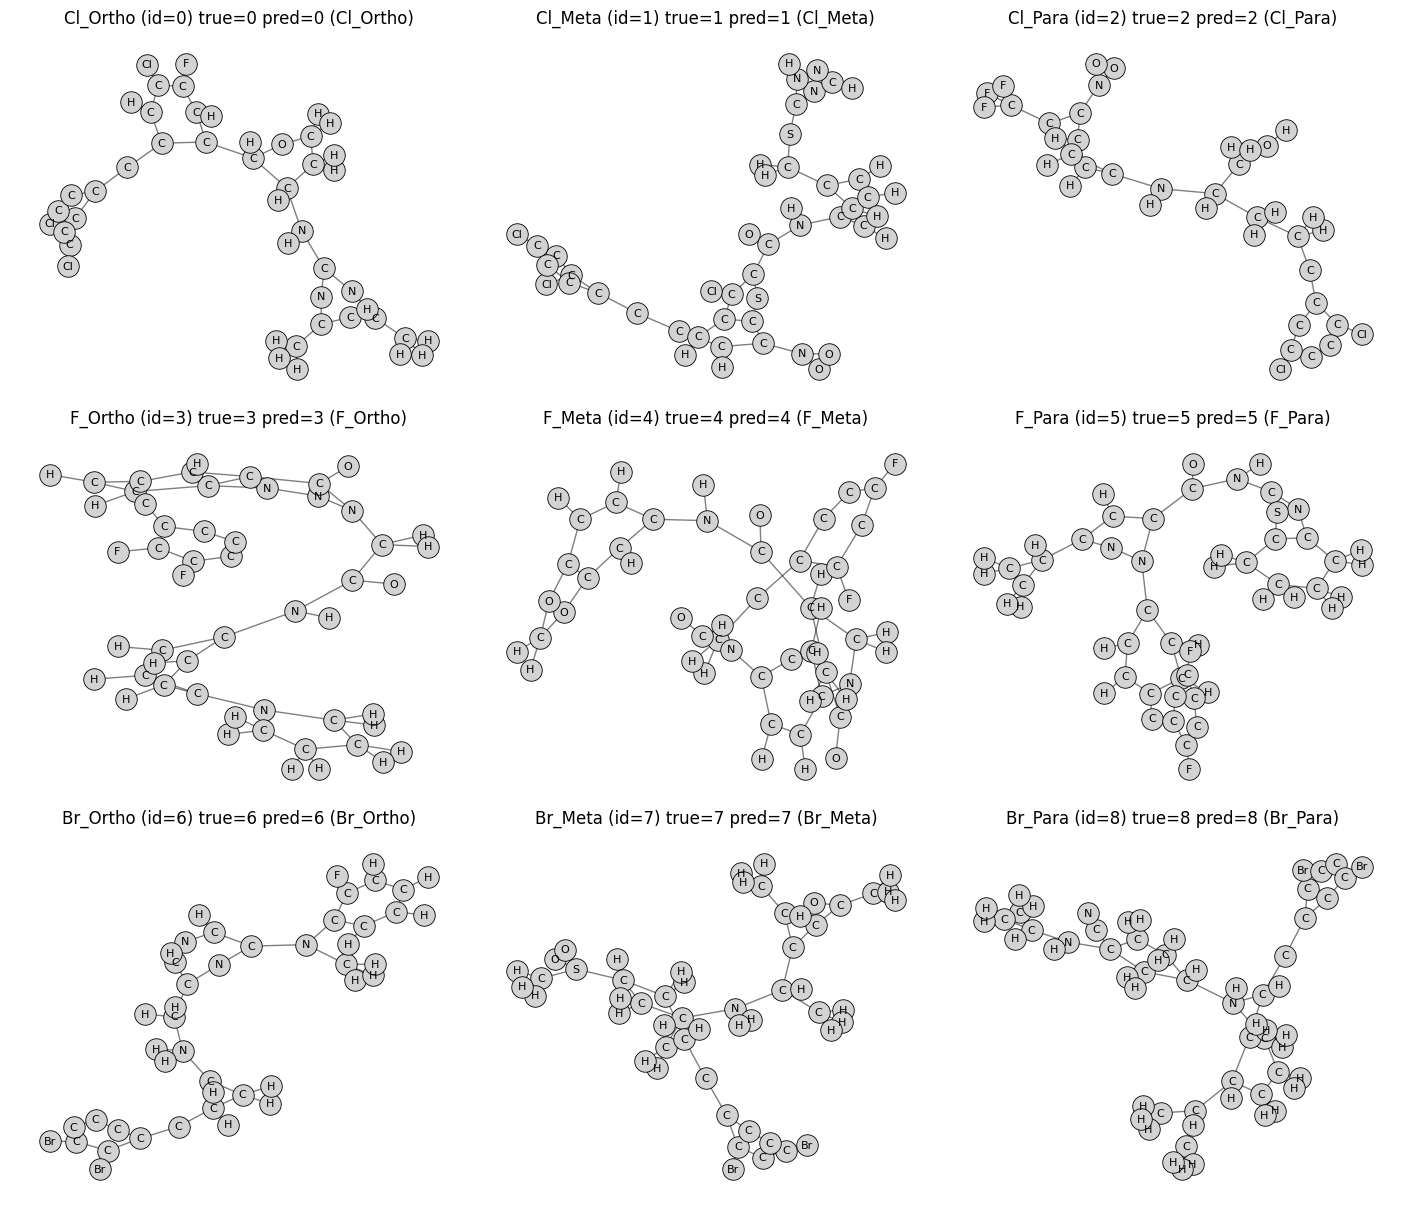

In [9]:
# ---- Visualize 1 sample graph per class with true vs predicted labels ----
import numpy as np
import torch
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx
from torch_geometric.data import Batch

# Class names (edit if you want different display names)
CLASS_NAMES = [
    'Cl_Ortho', 'Cl_Meta', 'Cl_Para',
    'F_Ortho', 'F_Meta', 'F_Para',
    'Br_Ortho', 'Br_Meta', 'Br_Para',
],
CLASS_NAMES = list(CLASS_NAMES)  # ensure plain list
if len(CLASS_NAMES) == 1 and isinstance(CLASS_NAMES[0], (list, tuple)):
    CLASS_NAMES = list(CLASS_NAMES[0])

def _infer_atom_list_from_x(x: torch.Tensor):
    # Your earlier code uses either 9 atoms (no H) or 10 atoms (with H).
    if x.size(-1) == 10:
        return ['C', 'N', 'O', 'S', 'F', 'Cl', 'Br', 'I', 'P', 'H']
    if x.size(-1) == 9:
        return ['C', 'N', 'O', 'S', 'F', 'Cl', 'Br', 'I', 'P']
    return [f'f{i}' for i in range(int(x.size(-1)))]

@torch.no_grad()
def predict_label(model, data, device):
    model.eval()
    b = Batch.from_data_list([data]).to(device)
    logits = model(b)
    return int(logits.argmax(dim=-1).item())

def _run_loader(model, loader, device, train: bool, optimizer=None):
    if train:
        model.train()
    else:
        model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0
    for batch in loader:
        batch = batch.to(device)
        logits = model(batch)
        yy = batch.y.view(-1).to(device)
        loss = F.cross_entropy(logits, yy)
        if train:
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
        total_loss += float(loss.item()) * yy.size(0)
        total_correct += int((logits.argmax(dim=-1) == yy).sum().item())
        total_examples += int(yy.size(0))
    return (total_loss / max(1, total_examples)), (total_correct / max(1, total_examples))

def train_single_model_no_test_leak(dataset, seed: int = 0, fold_id: int = 1):
    """
    Trains ONE model for visualization without test leakage:
    - create trainval/test with `make_splits_indices`
    - pick one CV fold inside trainval to form train/val
    - early-stop on val
    - evaluate on test ONCE at the end
    Returns: (model, device, test_idx)
    """
    set_seed(seed)
    device = get_device()

    y = np.array([dataset[i].y.item() for i in range(len(dataset))], dtype=np.int64)
    trainval_idx, test_idx, folds = make_splits_indices(y=y, seed=int(seed), test_size=TEST_SIZE, k_folds=K_FOLDS)
    if not folds:
        raise ValueError("No folds produced; check K_FOLDS and dataset size.")
    fold_id = int(fold_id)
    if fold_id < 1 or fold_id > len(folds):
        raise ValueError(f"fold_id must be in [1, {len(folds)}]")

    train_idx, val_idx = folds[fold_id - 1]

    train_loader = DataLoader(dataset.index_select(torch.tensor(train_idx)), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(dataset.index_select(torch.tensor(val_idx)), batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(dataset.index_select(torch.tensor(test_idx)), batch_size=BATCH_SIZE, shuffle=False)

    sample0 = dataset[0]
    model = GINE4Layer(
        in_dim=int(sample0.x.size(-1)),
        edge_dim=int(sample0.edge_attr.size(-1)),
        hidden_dim=HIDDEN_DIM,
        num_classes=int(dataset.num_classes),
        num_layers=4,
        dropout=DROPOUT,
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=SCHED_FACTOR, patience=SCHED_PATIENCE, min_lr=MIN_LR
    )

    best_state = None
    best_val_loss = float('inf')
    epochs_no_improve = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        _train_loss, _train_acc = _run_loader(model, train_loader, device, train=True, optimizer=optimizer)
        val_loss, val_acc = _run_loader(model, val_loader, device, train=False)
        scheduler.step(val_loss)

        improved = (best_val_loss - val_loss) > MIN_DELTA
        if improved:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if VERBOSE and (epoch == 1 or epoch % 10 == 0):
            print(f"[viz-train] Epoch {epoch:03d} | val_loss={val_loss:.4f} | val_acc={val_acc:.3f}")

        if epochs_no_improve >= EARLY_STOP_PATIENCE:
            if VERBOSE:
                print(f"[viz-train] Early stop at epoch {epoch} (best val loss {best_val_loss:.4f}).")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)

    # Evaluate test ONCE (no leakage)
    test_loss, test_acc = _run_loader(model, test_loader, device, train=False)
    print(f"[viz-eval] Test (single pass): loss={test_loss:.6f} acc={test_acc:.4f}")
    return model, device, np.array(test_idx, dtype=np.int64)

def _plot_graph(ax, data, title: str):
    G = to_networkx(data, to_undirected=True)
    pos = nx.spring_layout(G, seed=0)
    atom_list = _infer_atom_list_from_x(data.x)
    labels = {}
    for i in range(data.num_nodes):
        if data.x.dim() == 2 and int(data.x.size(-1)) == len(atom_list):
            labels[i] = atom_list[int(data.x[i].argmax().item())]
        else:
            labels[i] = str(i)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=240, node_color='lightgray', edgecolors='k', linewidths=0.6)
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.5, width=1.0)
    nx.draw_networkx_labels(G, pos, ax=ax, labels=labels, font_size=8)
    ax.set_title(title)
    ax.set_axis_off()

# Choose which seed/fold for visualization (uses the same split logic; no retraining of full CV required)
VIZ_SEED = 0
VIZ_FOLD = 1
print(f"Visualizing predictions using seed={VIZ_SEED}, fold={VIZ_FOLD} (early-stop on val; test evaluated once).")

viz_model, viz_device, viz_test_idx = train_single_model_no_test_leak(dataset, seed=VIZ_SEED, fold_id=VIZ_FOLD)

# Pick one test example per class (0..8)
by_class = {c: None for c in range(len(CLASS_NAMES))}
for i in viz_test_idx.tolist():
    y = int(dataset[i].y.item())
    if by_class.get(y) is None:
        by_class[y] = i
    if all(v is not None for v in by_class.values()):
        break

missing = [c for c, v in by_class.items() if v is None]
if missing:
    print(f"WARNING: could not find test examples for classes: {missing}")

fig, axes = plt.subplots(3, 3, figsize=(14, 12), constrained_layout=True)
for c in range(len(CLASS_NAMES)):
    ax = axes[c // 3, c % 3]
    idx = by_class[c]
    if idx is None:
        ax.set_axis_off()
        ax.set_title(f"{CLASS_NAMES[c]} (id={c}) MISSING")
        continue
    d = dataset[idx]
    true_c = int(d.y.item())
    pred_c = predict_label(viz_model, d, viz_device)
    title = f"{CLASS_NAMES[c]} (id={c}) true={true_c} pred={pred_c} ({CLASS_NAMES[pred_c]})"
    _plot_graph(ax, d, title)
plt.show()